# [chart] Notebook 02 -- Analiza Univariata

**Proiect:** Modelarea si prognoza volatilitatii S&P 500 sub influenta sentimentului din stiri financiare

**Disciplina:** Analiza avansata a seriilor de timp si previziune -- Master Statistica Aplicata si Data Science

---

## Structura

| Sectiune | Continut |
|---|---|
| 3.1 | Specificarea seriilor si obiectivul de prognoza |
| 3.2 | Train/test split si metodologia de evaluare |
| 3.3 | Teste preliminare: stationaritate, ACF/PACF, Ljung-Box, ARCH-LM |
| 3.4 | Tehnici de netezire exponentiala (ETS/Holt-Winters) |
| 3.5 | Modele ARMA/ARIMA/SARIMA |
| 3.6 | Persistenta si memorie lunga -- ARFIMA |
| 3.7 | Modele ARCH/GARCH si extensii |
| 3.8 | Modele State Space si filtrul Kalman |
| 3.9 | Analiza spectrala |
| 3.10 | Modele neliniare: NNAR si SETAR |
| 3.11 | Compararea performantei predictive + Diebold-Mariano |

> **Nota metodologica:** In acest notebook folosim **exclusiv** seria $r_t$ (log-randamente)
> si derivatele sale ($r_t^2$, $|r_t|$, $rv_{22d}$). Sentimentul din stiri NU intra in
> niciun model. Scopul este stabilirea unui **benchmark univariat** fata de care modelele
> cu sentiment (Notebook 03) vor fi comparate.


---
## §0. Setup si incarcare date

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.signal import periodogram

# Serii de timp -- statsmodels
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf as sm_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.structural import UnobservedComponents

# ARCH/GARCH
from arch import arch_model
from arch.unitroot import PhillipsPerron

# ML
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# pmdarima
try:
    from pmdarima import auto_arima
    PMDARIMA_OK = True
except ImportError:
    PMDARIMA_OK = False
    print("pmdarima nu e instalat -- ruleaza: uv pip install pmdarima")

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.figsize': (13, 5),
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA_PATH = Path('./data/processed/sp500_sentiment_daily.parquet')
FIG_PATH  = Path('./data/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df.index = pd.to_datetime(df.index)
df.index.freq = None

print(f"Dataset incarcat: {df.shape}")
print(f"Perioada: {df.index.min().date()} -> {df.index.max().date()}")
print(f"Coloane disponibile: {list(df.columns[:12])}...")


Dataset incarcat: (1758, 40)
Perioada: 2018-01-04 -> 2024-12-30
Coloane disponibile: ['close', 'adj_close', 'volume', 'vix', 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d', 'S_sum', 'S_mean', 'S_median']...


---
## 3.1 Specificarea seriilor si obiectivul de prognoza

Lucram cu **trei tipuri de serii**, fiecare cu obiectiv diferit:

| Serie | Simbol | Obiectiv |
|---|---|---|
| Log-randamente | $r_t = 100 \cdot \Delta \ln P_t$ | Prognoza punctuala a miscarii zilnice |
| Volatilitate proxy | $r_t^2$, $\|r_t\|$ | Proxy pentru volatilitatea realizata zilnica |
| Volatilitate realizata | $rv_{22d}$ | Volatilitate pe fereastra de 22 zile |

### De ce pretul ≠ volatilitatea

**Pretul** $P_t$ are **trend** (non-stationar, random walk cu drift pozitiv pe termen lung).
Nu il modelam direct.

**Randamentul** $r_t = 100 \cdot \ln(P_t/P_{t-1})$ este prima diferenta a log-pretului --
**stationar**, fara trend. Modelele ARIMA si GARCH opereaza pe randamente.

**Volatilitatea** nu este pretul si nu este nici randamentul -- este **dispersia** randamentelor.
O zi cu $r_t = +5\%$ si una cu $r_t = -5\%$ sunt la fel de volatile. De aceea proxy-ul corect
este $r_t^2$ sau $|r_t|$, iar modelele GARCH estimeaza explicit
$\sigma_t^2 = \text{Var}(r_t | \mathcal{F}_{t-1})$ -- varianta conditionata pe informatia
disponibila pana in $t-1$.


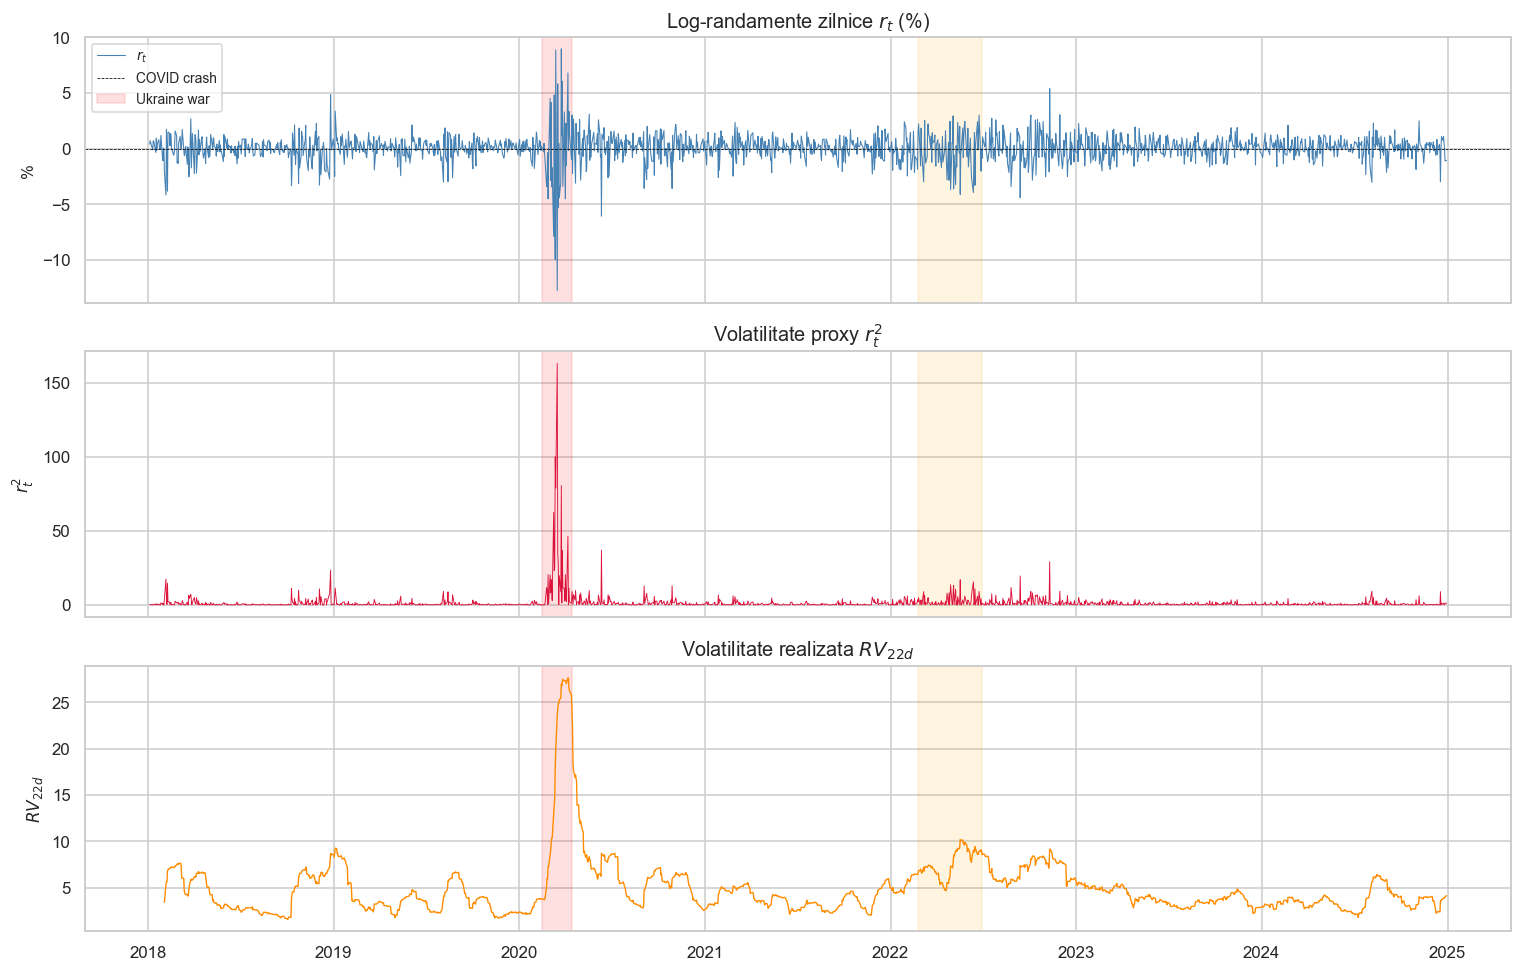

In [4]:
# Extragem seriile principale
r_t    = df['r_t'].dropna()
r_t_sq = df['r_t_sq'].dropna()
abs_rt = df['abs_r_t'].dropna()
rv22   = df['rv_22d'].dropna()

# Plot de prezentare
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(r_t.index, r_t.values, color='steelblue', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title('Log-randamente zilnice $r_t$ (%)')
axes[0].set_ylabel('%')

axes[1].plot(r_t_sq.index, r_t_sq.values, color='crimson', linewidth=0.6)
axes[1].set_title('Volatilitate proxy $r_t^2$')
axes[1].set_ylabel('$r_t^2$')

axes[2].plot(rv22.index, rv22.values, color='darkorange', linewidth=0.9)
axes[2].set_title('Volatilitate realizata $RV_{22d}$')
axes[2].set_ylabel('$RV_{22d}$')

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-15'),
               alpha=0.12, color='red')
    ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-06-30'),
               alpha=0.12, color='orange')

axes[0].legend(['$r_t$', 'COVID crash', 'Ukraine war'], fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_01_serii_principale.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 3.2 Train/test split si metodologia de evaluare

### Split temporal

```
Train: 2018-01-02 -> 2023-12-29   (6 ani, ~1508 zile de tranzactionare)
Test:  2024-01-02 -> 2024-12-30   (1 an,  ~251 zile de tranzactionare)
```

Ultimul an calendaristic complet ca set de test:
- Usor de justificat si de comunicat
- 2024 nu a fost vazut de niciun model in antrenament
- 251 de observatii sunt suficiente pentru o evaluare robusta

### Metodologia de forecast

**Rolling window (expanding):** la fiecare pas adaugam observatia reala la history
si re-estimam sau facem forecast din modelul existent.

### Metrici de evaluare

| Metrica | Formula | Utilizare |
|---|---|---|
| RMSE | $\sqrt{\frac{1}{n}\sum (y_t - \hat{y}_t)^2}$ | Randamente si volatilitate |
| MAE | $\frac{1}{n}\sum \|y_t - \hat{y}_t\|$ | Randamente si volatilitate |
| QLIKE | $\frac{\sigma_t^2}{h_t} - \ln\frac{\sigma_t^2}{h_t} - 1$ | Modele GARCH (asimetric) |

**Nota:** MAPE nu se foloseste pe $r_t$ deoarece randamentele pot fi aproape de zero,
ceea ce face raportul instabil numeric.


Train: 2018-01-04 -> 2023-12-29  (1507 obs)
Test:  2024-01-02  -> 2024-12-30   (251 obs)


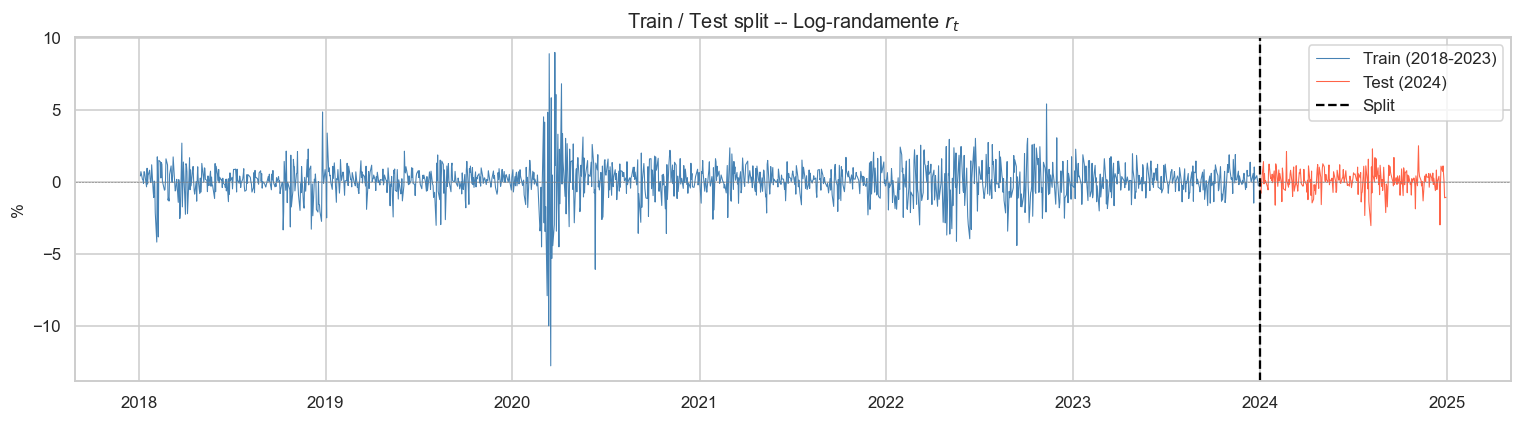


Functii de metrici definite. Dict 'results' initializat.


In [5]:
# Split
TRAIN_END  = '2023-12-31'
TEST_START = '2024-01-01'

r_train = r_t[r_t.index <= TRAIN_END]
r_test  = r_t[r_t.index >= TEST_START]
rv_train = rv22[rv22.index <= TRAIN_END]
rv_test  = rv22[rv22.index >= TEST_START]

print(f"Train: {r_train.index.min().date()} -> {r_train.index.max().date()}  ({len(r_train)} obs)")
print(f"Test:  {r_test.index.min().date()}  -> {r_test.index.max().date()}   ({len(r_test)} obs)")

# Grafic split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(r_train.index, r_train.values, color='steelblue', linewidth=0.7, label='Train (2018-2023)')
ax.plot(r_test.index,  r_test.values,  color='tomato',    linewidth=0.7, label='Test (2024)')
ax.axvline(pd.Timestamp(TEST_START), color='black', linestyle='--', linewidth=1.5, label='Split')
ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
ax.set_title('Train / Test split -- Log-randamente $r_t$')
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_02_train_test_split.png', dpi=130, bbox_inches='tight')
plt.show()

# Functii de metrici
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_fn(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def qlike(sigma2_true, h_pred):
    h = np.maximum(h_pred, 1e-8)
    s = np.maximum(sigma2_true, 1e-8)
    return np.mean(s / h - np.log(s / h) - 1)

results = {}
print("\nFunctii de metrici definite. Dict 'results' initializat.")


---
## 3.3 Teste preliminare: stationaritate, ACF/PACF, Ljung-Box, ARCH-LM

Toate testele se aplica **exclusiv pe setul de antrenament (2018-2023)**.
Deciziile de modelare nu trebuie sa foloseasca informatie din test.


In [6]:
# ── Teste de stationaritate ───────────────────────────────────────────
def run_stationarity(series, name):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    pp = PhillipsPerron(s)
    print(f"{'─'*58}")
    print(f"  {name}  (n={len(s)})")
    print(f"  ADF   stat={adf_stat:8.3f}  p={adf_p:.4f}  "
          f"-> {'STATIONAR  OK' if adf_p < 0.05 else 'NON-STATIONAR  ATENTIE'}")
    print(f"  KPSS  stat={kpss_stat:8.3f}  p={kpss_p:.4f}  "
          f"-> {'STATIONAR  OK' if kpss_p > 0.05 else 'NON-STATIONAR  ATENTIE'}")
    print(f"  PP    stat={pp.stat:8.3f}  p={pp.pvalue:.4f}  "
          f"-> {'STATIONAR  OK' if pp.pvalue < 0.05 else 'NON-STATIONAR  ATENTIE'}")

print("=== TESTE STATIONARITATE -- setul TRAIN 2018-2023 ===")
run_stationarity(r_train,      'r_t   (randamente)')
run_stationarity(r_train**2,   'r_t^2 (volatilitate proxy)')
run_stationarity(r_train.abs(),'|r_t| (volatilitate proxy)')
run_stationarity(rv_train,     'rv_22d (vol. realizata)')


=== TESTE STATIONARITATE -- setul TRAIN 2018-2023 ===
──────────────────────────────────────────────────────────
  r_t   (randamente)  (n=1507)
  ADF   stat= -11.859  p=0.0000  -> STATIONAR  OK
  KPSS  stat=   0.041  p=0.1000  -> STATIONAR  OK
  PP    stat= -45.573  p=0.0000  -> STATIONAR  OK
──────────────────────────────────────────────────────────
  r_t^2 (volatilitate proxy)  (n=1507)
  ADF   stat=  -6.534  p=0.0000  -> STATIONAR  OK
  KPSS  stat=   0.121  p=0.1000  -> STATIONAR  OK
  PP    stat= -31.552  p=0.0000  -> STATIONAR  OK
──────────────────────────────────────────────────────────
  |r_t| (volatilitate proxy)  (n=1507)
  ADF   stat=  -6.002  p=0.0000  -> STATIONAR  OK
  KPSS  stat=   0.137  p=0.1000  -> STATIONAR  OK
  PP    stat= -38.984  p=0.0000  -> STATIONAR  OK
──────────────────────────────────────────────────────────
  rv_22d (vol. realizata)  (n=1487)
  ADF   stat=  -3.313  p=0.0143  -> STATIONAR  OK
  KPSS  stat=   0.129  p=0.1000  -> STATIONAR  OK
  PP    stat=  

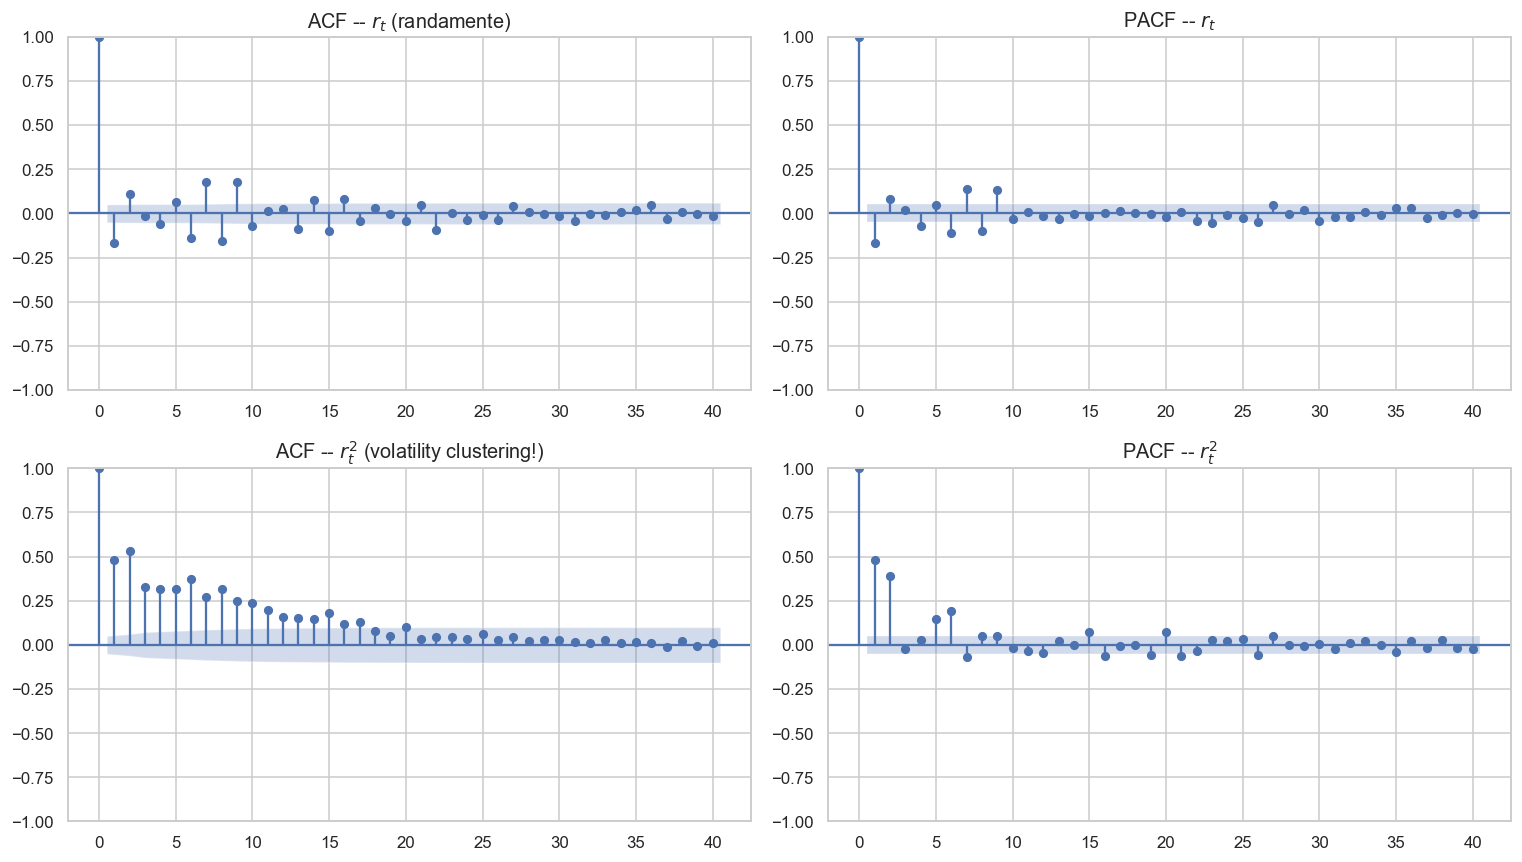

In [7]:
# ── ACF/PACF ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( r_train,    lags=40, ax=axes[0,0], title='ACF -- $r_t$ (randamente)')
plot_pacf(r_train,    lags=40, ax=axes[0,1], title='PACF -- $r_t$', method='ywm')
plot_acf( r_train**2, lags=40, ax=axes[1,0], title='ACF -- $r_t^2$ (volatility clustering!)')
plot_pacf(r_train**2, lags=40, ax=axes[1,1], title='PACF -- $r_t^2$', method='ywm')

plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_03_acf_pacf_train.png', dpi=130, bbox_inches='tight')
plt.show()

print(
)


In [8]:
# ── Ljung-Box ────────────────────────────────────────────────────────
lb_rt  = acorr_ljungbox(r_train.dropna(), lags=[5, 10, 20], return_df=True)
lb_rt2 = acorr_ljungbox((r_train**2).dropna(), lags=[5, 10, 20], return_df=True)

print("=== LJUNG-BOX pe r_t ===")
print(lb_rt.round(4))
print("=== LJUNG-BOX pe r_t^2 ===")
print(lb_rt2.round(4))
print(
)


=== LJUNG-BOX pe r_t ===
     lb_stat  lb_pvalue
5    72.2193        0.0
10  243.4760        0.0
20  297.5158        0.0
=== LJUNG-BOX pe r_t^2 ===
      lb_stat  lb_pvalue
5   1246.5081        0.0
10  1897.9730        0.0
20  2189.2710        0.0



In [9]:
# ── ARCH-LM Test ─────────────────────────────────────────────────────
stat, p, *_ = het_arch(r_train.dropna(), nlags=10)
print(f"=== ARCH-LM TEST pe r_train (lags=10) ===")
print(f"  Statistica LM : {stat:.4f}")
print(f"  p-value       : {p:.6f}")
print(f"  Decizie       : {'EFECTE ARCH PREZENTE -> GARCH justificat  OK' if p < 0.05 else 'Nu exista efecte ARCH'}")
print(
    "Acest comportament justifica utilizarea modelelor ARCH/GARCH."
)


=== ARCH-LM TEST pe r_train (lags=10) ===
  Statistica LM : 590.5224
  p-value       : 0.000000
  Decizie       : EFECTE ARCH PREZENTE -> GARCH justificat  OK
Acest comportament justifica utilizarea modelelor ARCH/GARCH.


---
## 3.4 Tehnici de netezire exponentiala (ETS / Holt-Winters)

Modele de netezire sunt **benchmark-uri naive**: daca un model mai complex nu le depaseste,
complexitatea sa nu e justificata.

Aplicam pe $r_t$ si pe $rv_{22d}$:
- **SES** -- Simple Exponential Smoothing (fara trend, fara sezonalitate)
- **Holt** -- Double ES (cu trend)
- **Holt-Winters** -- Triple ES (cu trend + sezonalitate $s=5$)
- **Naive (mean)** -- forecast = media seriei de antrenament


In [13]:
# ── ETS pe r_t ───────────────────────────────────────────────────────
ets_specs = {
    'SES':          ExponentialSmoothing(r_train, trend=None,  seasonal=None),
    'Holt':         ExponentialSmoothing(r_train, trend='add', seasonal=None),
    'Holt-Winters': ExponentialSmoothing(r_train, trend='add', seasonal='add',
                                          seasonal_periods=5),
}
ets_fits  = {n: m.fit(optimized=True) for n, m in ets_specs.items()}
ets_fcast = {n: f.forecast(len(r_test)) for n, f in ets_fits.items()}

# Naive
naive_fc = np.full(len(r_test), r_train.mean())

print(f"=== ETS pe r_t -- Test 2024 ===")
print(f"{'Model':<18} {'RMSE':>8} {'MAE':>8}")
print("-" * 38)
for name, fc in ets_fcast.items():
    r_e = rmse(r_test.values, fc.values)
    m_e = mae_fn(r_test.values, fc.values)
    results[f'ETS_{name}'] = {'RMSE': r_e, 'MAE': m_e}
    print(f"  {name:<16} {r_e:8.4f} {m_e:8.4f}")

r_naive = rmse(r_test.values, naive_fc)
m_naive = mae_fn(r_test.values, naive_fc)
results['Naive_mean'] = {'RMSE': r_naive, 'MAE': m_naive}
print(f"  {'Naive (mean)':<16} {r_naive:8.4f} {m_naive:8.4f}")

=== ETS pe r_t -- Test 2024 ===
Model                  RMSE      MAE
--------------------------------------
  SES                0.7987   0.5909
  Holt               0.7974   0.5881
  Holt-Winters       0.8095   0.5938
  Naive (mean)       0.7987   0.5909


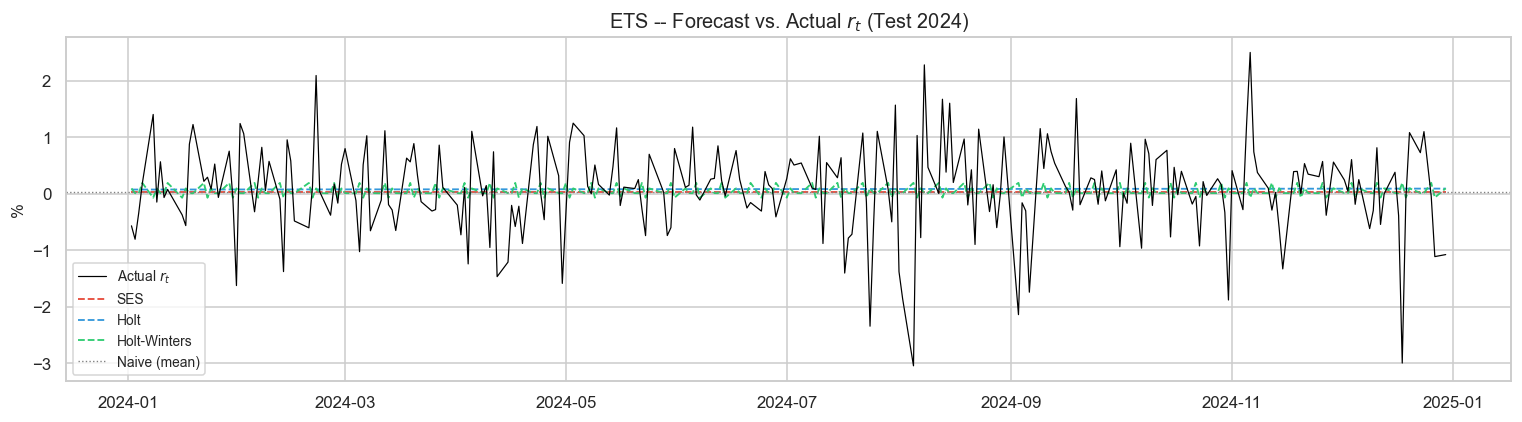

In [14]:
# ── Grafic ETS forecast ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(r_test.index, r_test.values, color='black', linewidth=0.8, label='Actual $r_t$', zorder=3)
colors = ['#e74c3c', '#3498db', '#2ecc71']
for (name, fc), col in zip(ets_fcast.items(), colors):
    ax.plot(r_test.index, fc.values, linewidth=1.2, color=col, linestyle='--', label=name)
ax.axhline(r_train.mean(), color='gray', linewidth=0.9, linestyle=':', label='Naive (mean)')
ax.set_title('ETS -- Forecast vs. Actual $r_t$ (Test 2024)')
ax.set_ylabel('%')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_04_ets_forecast.png', dpi=130, bbox_inches='tight')
plt.show()

print(
)


In [18]:
# ── ETS pe rv_22d ────────────────────────────────────────────────────
ets_rv = {
    'SES':          ExponentialSmoothing(rv_train, trend=None,  seasonal=None),
    'Holt':         ExponentialSmoothing(rv_train, trend='add', seasonal=None),
    'Holt-Winters': ExponentialSmoothing(rv_train, trend='add', seasonal='add',
                                          seasonal_periods=5),
}
ets_rv_fits  = {n: m.fit(optimized=True) for n, m in ets_rv.items()}
ets_rv_fcast = {n: f.forecast(len(rv_test)) for n, f in ets_rv_fits.items()}

print(f"=== ETS pe rv_22d -- Test 2024 ===")
print(f"{'Model':<18} {'RMSE':>8} {'MAE':>8}")
print("─" * 38)
for name, fc in ets_rv_fcast.items():
    n = min(len(rv_test), len(fc))
    r_e = rmse(rv_test.values[:n], fc.values[:n])
    m_e = mae_fn(rv_test.values[:n], fc.values[:n])
    results[f'ETS_{name}_rv'] = {'RMSE': r_e, 'MAE': m_e}
    print(f"  {name:<16} {r_e:8.4f} {m_e:8.4f}")


=== ETS pe rv_22d -- Test 2024 ===
Model                  RMSE      MAE
──────────────────────────────────────
  SES                1.1992   0.8748
  Holt               1.2287   0.9746
  Holt-Winters       0.9842   0.7450


---
## 3.5 Modele ARMA/ARIMA/SARIMA

### Strategie

Deoarece $r_t$ este stationar ($d=0$), estimam **ARMA(p, q)** = ARIMA(p, 0, q).

1. Grid search $p \in [0,4]$, $q \in [0,4]$ -- selectam dupa AIC
2. Confirmare cu `auto_arima`
3. Diagnostic complet pe modelul castigator
4. Forecast rolling one-step-ahead pe test cu IC 95%

### SARIMA

Testam sezonalitate saptamanala $s=5$. Pe date financiare zilnice aceasta e rar semnificativa,
dar o verificam empiric.


In [19]:
# ── Grid search ARIMA(p,0,q) ─────────────────────────────────────────
from itertools import product as iproduct

print("Grid search ARIMA(p,0,q) pe r_train -- poate dura 1-2 minute...")
best_aic, best_order, best_model = np.inf, None, None
grid_rows = []

for p, q in iproduct(range(5), range(5)):
    try:
        m = ARIMA(r_train, order=(p, 0, q)).fit(method='innovations_mle', low_memory=True)
        grid_rows.append({'p': p, 'q': q, 'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2)})
        if m.aic < best_aic:
            best_aic, best_order, best_model = m.aic, (p, 0, q), m
    except Exception:
        pass

grid_df = pd.DataFrame(grid_rows).sort_values('AIC').reset_index(drop=True)
print("\n=== TOP 10 modele dupa AIC ===")
print(grid_df.head(10).to_string(index=False))
print(f"\n OK Model selectat: ARIMA{best_order}  AIC={best_aic:.2f}")


Grid search ARIMA(p,0,q) pe r_train -- poate dura 1-2 minute...

=== TOP 10 modele dupa AIC ===
 p  q     AIC     BIC
 3  3 4954.69 4997.24
 2  2 4955.48 4987.38
 3  4 4956.32 5004.18
 4  3 4956.33 5004.19
 2  3 4956.75 4993.98
 3  2 4956.77 4993.99
 2  4 4958.63 5001.18
 4  1 4977.47 5014.70
 4  2 4986.62 5029.16
 3  1 4986.73 5018.64

 OK Model selectat: ARIMA(3, 0, 3)  AIC=4954.69


In [20]:
# ── auto_arima ───────────────────────────────────────────────────────
if PMDARIMA_OK:
    aa = auto_arima(r_train, d=0, max_p=4, max_q=4,
                    information_criterion='aic', stepwise=True,
                    seasonal=False, suppress_warnings=True, error_action='ignore')
    print(f"auto_arima -> ARIMA{aa.order}  AIC={aa.aic():.2f}")
else:
    print("pmdarima indisponibil -- se foloseste modelul din grid search.")


auto_arima -> ARIMA(2, 0, 2)  AIC=4955.04


In [21]:
# ── Summary + diagnostic ────────────────────────────────────────────
print(best_model.summary())


                               SARIMAX Results                                
Dep. Variable:                    r_t   No. Observations:                 1507
Model:                 ARIMA(3, 0, 3)   Log Likelihood               -2469.347
Date:                Wed, 10 Jun 2026   AIC                           4954.694
Time:                        22:53:53   BIC                           4997.237
Sample:                             0   HQIC                          4970.539
                               - 1507                                         
Covariance Type:               approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0374      0.030      1.230      0.219      -0.022       0.097
ar.L1         -2.5596      0.181    -14.135      0.000      -2.915      -2.205
ar.L2         -2.3273      0.297     -7.831      0.0

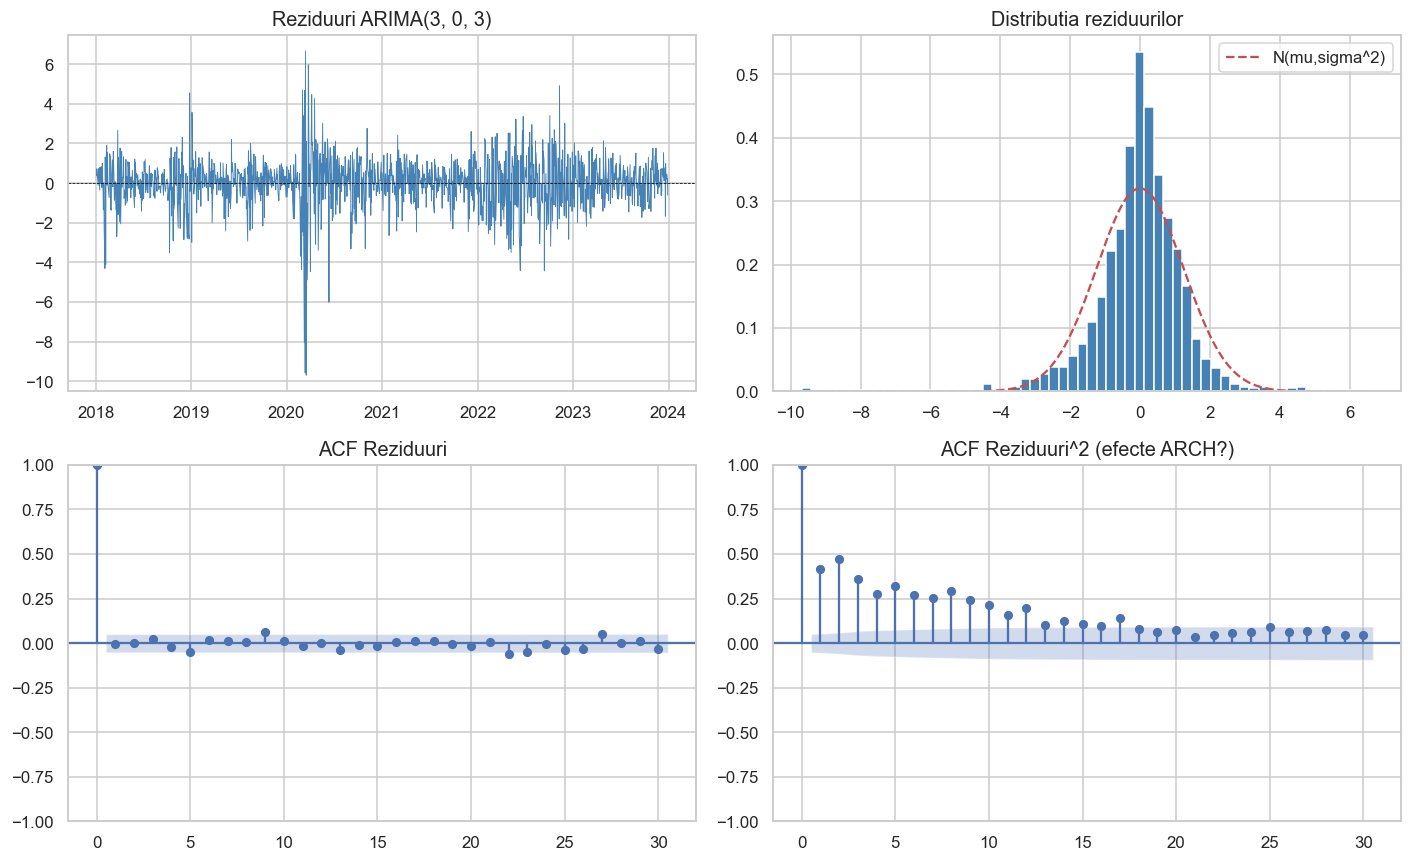

Ljung-Box reziduuri:
    lb_stat  lb_pvalue
5    5.8683     0.3192
10  12.4542     0.2558
20  16.3694     0.6935

Ljung-Box reziduuri^2:
      lb_stat  lb_pvalue
5   1055.2836        0.0
10  1549.1482        0.0
20  1770.4470        0.0



In [22]:
# ── Diagnostic reziduuri ─────────────────────────────────────────────
resid = best_model.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0,0].plot(resid.index, resid.values, linewidth=0.6, color='steelblue')
axes[0,0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0,0].set_title(f'Reziduuri ARIMA{best_order}')

axes[0,1].hist(resid.dropna(), bins=60, density=True, color='steelblue', edgecolor='white')
x = np.linspace(resid.min(), resid.max(), 300)
axes[0,1].plot(x, stats.norm.pdf(x, resid.mean(), resid.std()), 'r--', label='N(mu,sigma^2)')
axes[0,1].set_title('Distributia reziduurilor')
axes[0,1].legend()

plot_acf( resid.dropna(),    lags=30, ax=axes[1,0], title='ACF Reziduuri')
plot_acf((resid**2).dropna(), lags=30, ax=axes[1,1], title='ACF Reziduuri^2 (efecte ARCH?)')

plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_05_arima_diagnostic.png', dpi=130, bbox_inches='tight')
plt.show()

lb_r  = acorr_ljungbox(resid.dropna(), lags=[5,10,20], return_df=True)
lb_r2 = acorr_ljungbox((resid**2).dropna(), lags=[5,10,20], return_df=True)
print("Ljung-Box reziduuri:"); print(lb_r.round(4))
print("\nLjung-Box reziduuri^2:"); print(lb_r2.round(4))
print(
)


Forecast ARIMA(3, 0, 3) rolling pe test 2024...
ARIMA(3, 0, 3)  RMSE=0.8229  MAE=0.6203


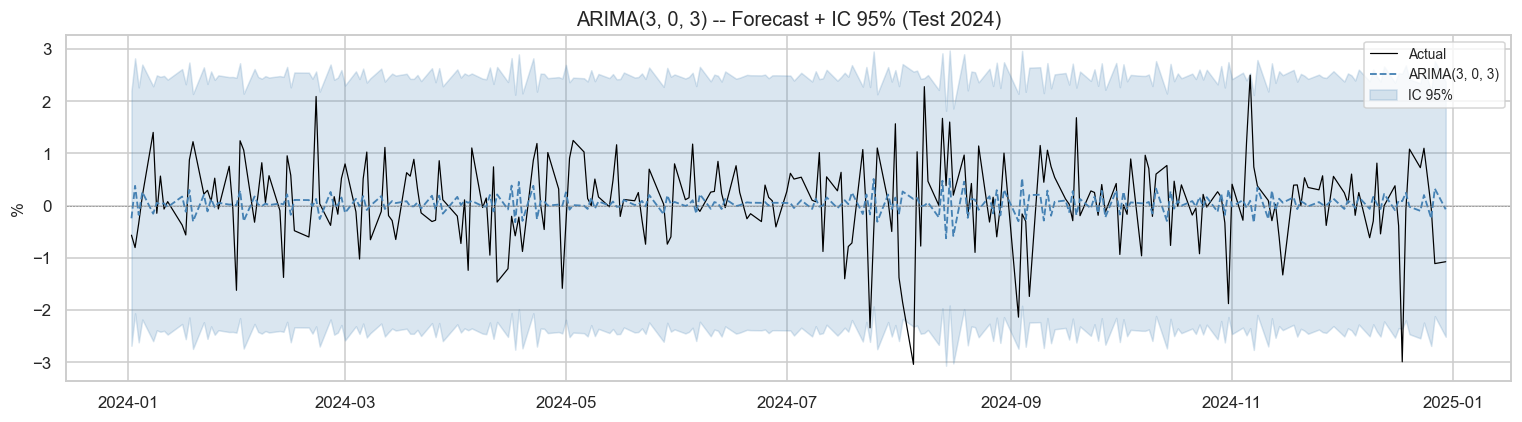

In [23]:
# ── Forecast ARIMA rolling one-step-ahead ────────────────────────────
print(f"Forecast ARIMA{best_order} rolling pe test 2024...")
arima_preds = []
history = r_train.copy()

for t in range(len(r_test)):
    m_t = ARIMA(history, order=best_order).fit(method='innovations_mle', low_memory=True)
    fc  = m_t.forecast(steps=1)
    arima_preds.append(float(fc.iloc[0]))
    history = pd.concat([history, r_test.iloc[[t]]])

arima_preds = np.array(arima_preds)
r_arima = rmse(r_test.values, arima_preds)
m_arima = mae_fn(r_test.values, arima_preds)
results[f'ARIMA{best_order}'] = {'RMSE': r_arima, 'MAE': m_arima}
print(f"ARIMA{best_order}  RMSE={r_arima:.4f}  MAE={m_arima:.4f}")

sigma_resid = float(resid.std())
ci_lo = arima_preds - 1.96 * sigma_resid
ci_hi = arima_preds + 1.96 * sigma_resid

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(r_test.index, r_test.values, color='black', linewidth=0.8, label='Actual')
ax.plot(r_test.index, arima_preds, color='steelblue', linewidth=1.2,
        linestyle='--', label=f'ARIMA{best_order}')
ax.fill_between(r_test.index, ci_lo, ci_hi, alpha=0.2, color='steelblue', label='IC 95%')
ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
ax.set_title(f'ARIMA{best_order} -- Forecast + IC 95% (Test 2024)')
ax.set_ylabel('%')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_06_arima_forecast.png', dpi=130, bbox_inches='tight')
plt.show()


In [24]:
# ── SARIMA(1,0,1)(1,0,1)[5] ──────────────────────────────────────────
print("Estimare SARIMA(1,0,1)(1,0,1)[5]...")
try:
    sarima = ARIMA(r_train, order=(1,0,1), seasonal_order=(1,0,1,5)
                   ).fit(method='innovations_mle', low_memory=True)
    sarima_fc = sarima.forecast(len(r_test))
    r_s = rmse(r_test.values, sarima_fc.values)
    m_s = mae_fn(r_test.values, sarima_fc.values)
    results['SARIMA(1,0,1)(1,0,1)[5]'] = {'RMSE': r_s, 'MAE': m_s}
    print(f"SARIMA  AIC={sarima.aic:.2f}  RMSE={r_s:.4f}  MAE={m_s:.4f}")
    print(f"ARIMA   AIC={best_model.aic:.2f}  RMSE={r_arima:.4f}  MAE={m_arima:.4f}")
    if sarima.aic < best_model.aic:
        print(" OK SARIMA imbunatateste AIC -- exista pattern saptamanal.")
    else:
        print(" INFO  SARIMA nu imbunatateste AIC -- sezonalitate saptamanala nesemnificativa.")
except Exception as e:
    print(f"SARIMA a esuat: {e}")


Estimare SARIMA(1,0,1)(1,0,1)[5]...
SARIMA  AIC=5045.56  RMSE=0.7990  MAE=0.5912
ARIMA   AIC=4954.69  RMSE=0.8229  MAE=0.6203
 INFO  SARIMA nu imbunatateste AIC -- sezonalitate saptamanala nesemnificativa.


---
## 3.6 Persistenta si memorie lunga -- verificare ARFIMA

Memoria lunga implica $d \in (0, 0.5)$ in procesul ARFIMA(p, d, q).
Caracterizata prin ACF cu scadere **hiperbolica** (lenta), nu exponentiala.

Verificam prin **exponentul Hurst** ($H$):
- $H \approx 0.5$ -> mers aleator, fara memorie lunga
- $H > 0.5$ -> memorie lunga / persistenta

**Asteptam:** $H \approx 0.5$ pentru $r_t$ si $H > 0.5$ pentru $r_t^2$, $rv_{22d}$.


In [25]:
# ── Exponent Hurst prin R/S ──────────────────────────────────────────
def hurst_rs(series, min_n=10):
    s = series.dropna().values
    n = len(s)
    ns, rs_vals = [], []
    for size in [n // k for k in range(2, min(20, n // min_n + 1))]:
        if size < min_n:
            continue
        n_chunks = n // size
        rs_chunk = []
        for i in range(n_chunks):
            chunk = s[i*size:(i+1)*size]
            dev = np.cumsum(chunk - chunk.mean())
            rng = dev.max() - dev.min()
            std_c = chunk.std(ddof=1)
            if std_c > 0:
                rs_chunk.append(rng / std_c)
        if rs_chunk:
            ns.append(size)
            rs_vals.append(np.mean(rs_chunk))
    H, _ = np.polyfit(np.log(ns), np.log(rs_vals), 1)
    return H

print("=== EXPONENT HURST (R/S) -- setul TRAIN ===")
for serie, name in [(r_train, 'r_t'),
                    (r_train**2, 'r_t^2'),
                    (r_train.abs(), '|r_t|'),
                    (rv_train, 'rv_22d')]:
    H = hurst_rs(serie)
    interp = ('memorie lunga  OK' if H > 0.55 else
              'mers aleator'    if 0.45 <= H <= 0.55 else
              'anti-persistenta')
    print(f"  {name:<12}  H = {H:.3f}  -> {interp}")

print(
)


=== EXPONENT HURST (R/S) -- setul TRAIN ===
  r_t           H = 0.540  -> mers aleator
  r_t^2         H = 0.897  -> memorie lunga  OK
  |r_t|         H = 0.956  -> memorie lunga  OK
  rv_22d        H = 0.881  -> memorie lunga  OK



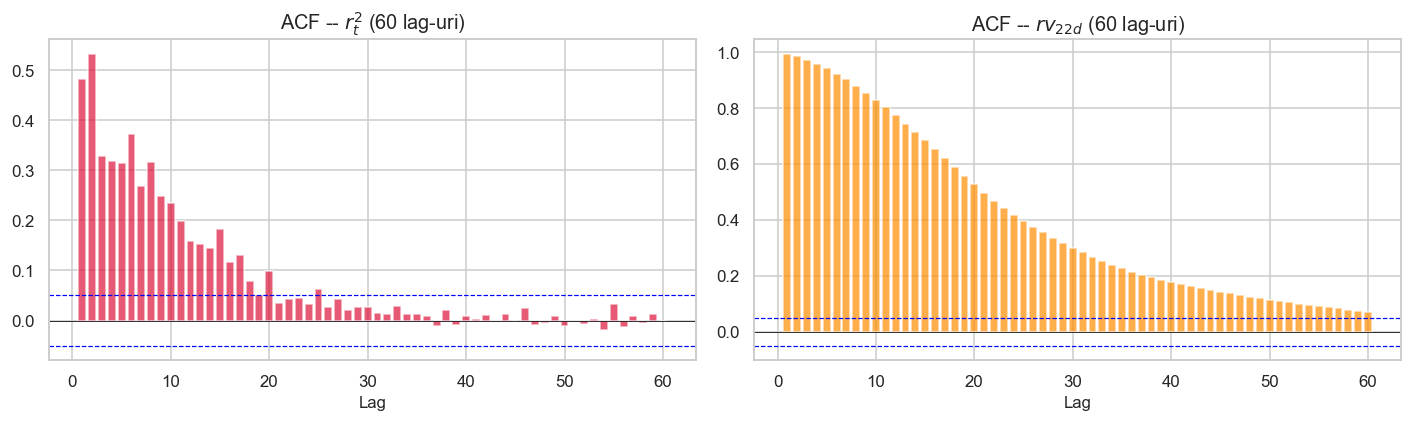

Daca ACF scade lent (mai mult de lag 20) -> indiciu de memorie lunga in volatilitate.


In [26]:
# ── Vizualizare ACF la lag-uri mari ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lags_r = np.arange(1, 61)
acf_rt2  = sm_acf((r_train**2).dropna(), nlags=60, fft=True)[1:]
acf_rv22 = sm_acf(rv_train.dropna(), nlags=60, fft=True)[1:]
ci_bound = 1.96 / np.sqrt(len(r_train))

for ax, acf_vals, title, color in [
    (axes[0], acf_rt2,  'ACF -- $r_t^2$ (60 lag-uri)',   'crimson'),
    (axes[1], acf_rv22, 'ACF -- $rv_{22d}$ (60 lag-uri)', 'darkorange'),
]:
    ax.bar(lags_r, acf_vals, color=color, alpha=0.7)
    ax.axhline(0,         color='black', linewidth=0.5)
    ax.axhline( ci_bound, color='blue',  linewidth=0.8, linestyle='--')
    ax.axhline(-ci_bound, color='blue',  linewidth=0.8, linestyle='--')
    ax.set_title(title); ax.set_xlabel('Lag')

plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_07_long_memory_acf.png', dpi=130, bbox_inches='tight')
plt.show()

print("Daca ACF scade lent (mai mult de lag 20) -> indiciu de memorie lunga in volatilitate.")


---
## 3.7 Modele ARCH/GARCH si extensii

### Ecuatii principale

**GARCH(1,1):**
$$\sigma_t^2 = \omega + \alpha_1 \varepsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

Conditie de stationaritate: $\alpha_1 + \beta_1 < 1$.
Persistenta totala: cu cat $\alpha + \beta$ e mai aproape de 1, cu atat socurile de
volatilitate dureaza mai mult.

**EGARCH(1,1):**
$$\ln \sigma_t^2 = \omega + \alpha \frac{|\varepsilon_{t-1}|}{\sigma_{t-1}} + \gamma \frac{\varepsilon_{t-1}}{\sigma_{t-1}} + \beta \ln \sigma_{t-1}^2$$

Coeficientul $\gamma < 0$ captureaza efectul **leverage** -- stirile negative amplifica
volatilitatea mai mult decat stirile pozitive de aceeasi magnitudine.

**GJR-GARCH(1,1):**
$$\sigma_t^2 = \omega + (\alpha + \gamma \mathbf{1}_{\varepsilon_{t-1}<0}) \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Asimetrie alternativa prin indicator pentru randamente negative.


In [27]:
# ── Estimare modele GARCH ────────────────────────────────────────────
garch_specs = {
    'ARCH(5)':        arch_model(r_train, vol='ARCH',  p=5, dist='normal'),
    'GARCH(1,1)':     arch_model(r_train, vol='GARCH', p=1, q=1, dist='normal'),
    'GARCH(1,1)-t':   arch_model(r_train, vol='GARCH', p=1, q=1, dist='t'),
    'EGARCH(1,1)-t':  arch_model(r_train, vol='EGARCH',p=1, q=1, dist='t'),
    'GJR-GARCH(1,1)': arch_model(r_train, vol='GARCH', p=1, o=1, q=1, dist='t'),
}

garch_fits = {}
garch_rows = []

for name, spec in garch_specs.items():
    try:
        fit = spec.fit(disp='off', options={'maxiter': 500})
        garch_fits[name] = fit
        pr = fit.params
        ab = (round(float(pr.get('alpha[1]', 0)) + float(pr.get('beta[1]', 0)), 4)
              if 'alpha[1]' in pr.index else '-')
        garch_rows.append({'Model': name, 'AIC': round(fit.aic,1),
                           'BIC': round(fit.bic,1),
                           'LogLik': round(fit.loglikelihood,1),
                           'alpha+beta': ab})
        print(f" OK {name:<22}  AIC={fit.aic:.1f}  BIC={fit.bic:.1f}  alpha+beta={ab}")
    except Exception as e:
        print(f" ERR {name}: {e}")

garch_df = pd.DataFrame(garch_rows).set_index('Model')
print("=== TABEL COMPARATIV GARCH ===")
print(garch_df)


 OK ARCH(5)                 AIC=4338.6  BIC=4375.9  alpha+beta=0.2088
 OK GARCH(1,1)              AIC=4306.4  BIC=4327.7  alpha+beta=0.9758
 OK GARCH(1,1)-t            AIC=4233.1  BIC=4259.7  alpha+beta=0.9921
 OK EGARCH(1,1)-t           AIC=4245.6  BIC=4272.2  alpha+beta=1.3179
 OK GJR-GARCH(1,1)          AIC=4193.5  BIC=4225.4  alpha+beta=0.8506
=== TABEL COMPARATIV GARCH ===
                   AIC     BIC  LogLik  alpha+beta
Model                                             
ARCH(5)         4338.6  4375.9 -2162.3      0.2088
GARCH(1,1)      4306.4  4327.7 -2149.2      0.9758
GARCH(1,1)-t    4233.1  4259.7 -2111.6      0.9921
EGARCH(1,1)-t   4245.6  4272.2 -2117.8      1.3179
GJR-GARCH(1,1)  4193.5  4225.4 -2090.7      0.8506


In [28]:
# ── Summary model principal ──────────────────────────────────────────
best_garch_name = min(garch_fits, key=lambda k: garch_fits[k].aic)
print(f"Model cu AIC minim: {best_garch_name}")
print(garch_fits[best_garch_name].summary())


Model cu AIC minim: GJR-GARCH(1,1)
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                          r_t   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2090.74
Distribution:      Standardized Student's t   AIC:                           4193.49
Method:                  Maximum Likelihood   BIC:                           4225.40
                                              No. Observations:                 1507
Date:                      Wed, Jun 10 2026   Df Residuals:                     1506
Time:                              22:56:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------

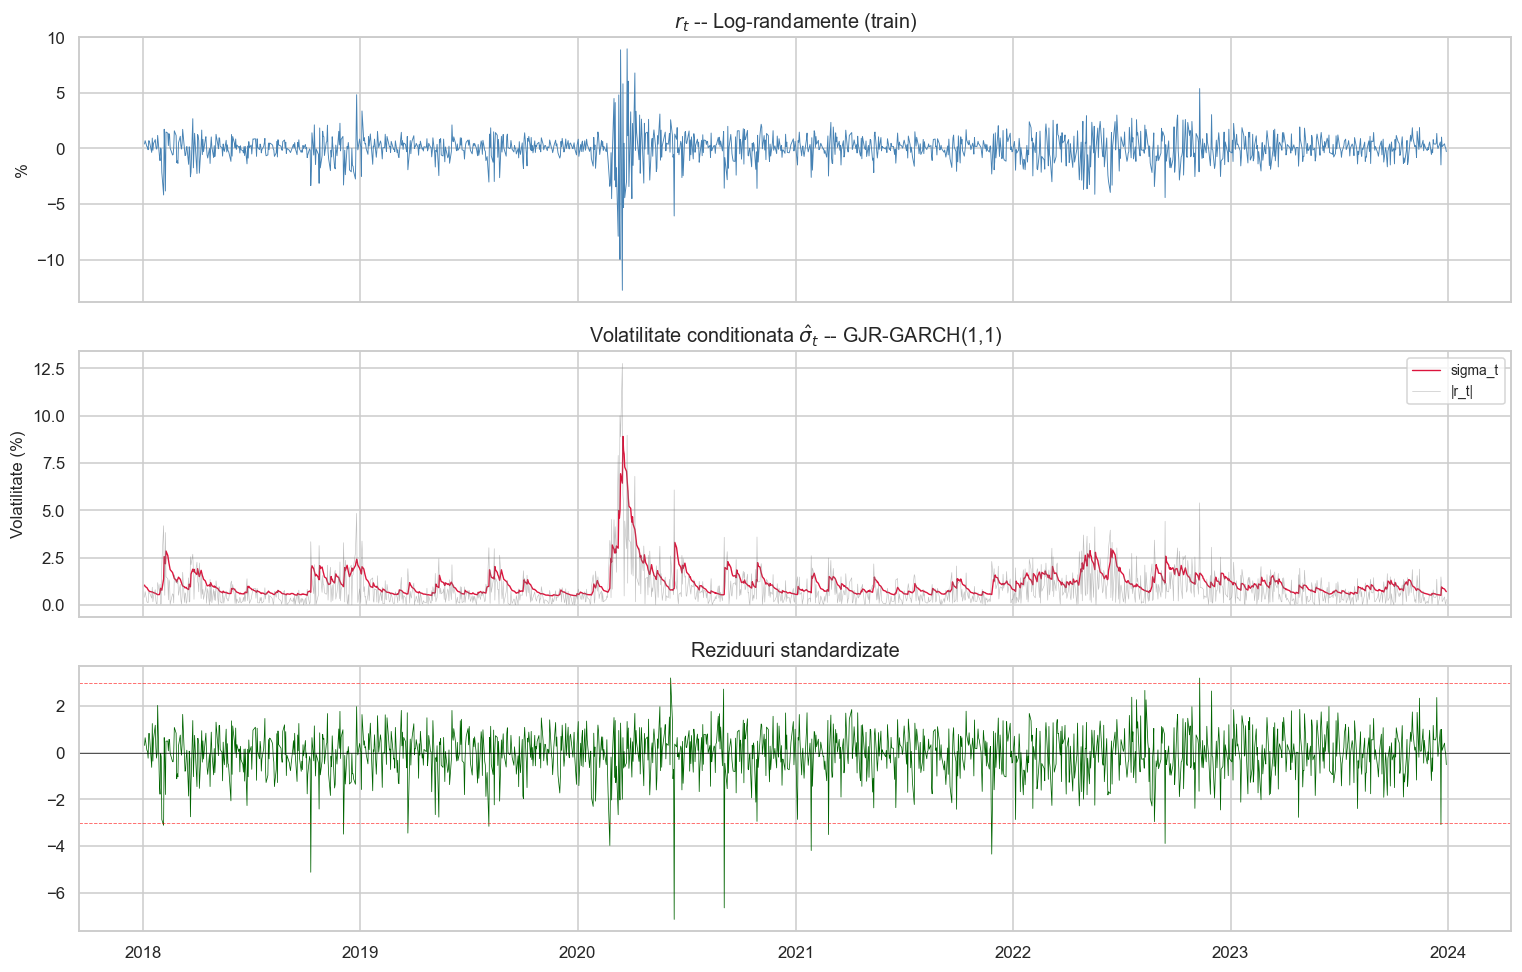

In [29]:
# ── Volatilitate conditionata + reziduuri standardizate ──────────────
best_gf   = garch_fits[best_garch_name]
cond_vol  = best_gf.conditional_volatility
std_resid = best_gf.std_resid

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(r_train.index, r_train.values, color='steelblue', linewidth=0.6)
axes[0].set_title('$r_t$ -- Log-randamente (train)')
axes[0].set_ylabel('%')

axes[1].plot(r_train.index, cond_vol.values,      color='crimson', linewidth=0.9, label='sigma_t')
axes[1].plot(r_train.index, r_train.abs().values,  color='gray',   linewidth=0.4, alpha=0.5, label='|r_t|')
axes[1].set_title(f'Volatilitate conditionata $\hat{{\sigma}}_t$ -- {best_garch_name}')
axes[1].set_ylabel('Volatilitate (%)')
axes[1].legend(fontsize=9)

axes[2].plot(r_train.index, std_resid.values, color='darkgreen', linewidth=0.5)
axes[2].axhline( 3, color='red', linewidth=0.6, linestyle='--', alpha=0.6)
axes[2].axhline(-3, color='red', linewidth=0.6, linestyle='--', alpha=0.6)
axes[2].axhline( 0, color='black', linewidth=0.4)
axes[2].set_title('Reziduuri standardizate')

plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_08_garch_cond_vol.png', dpi=130, bbox_inches='tight')
plt.show()


In [30]:
# ── Diagnostic reziduuri GARCH ────────────────────────────────────────
print(f"=== DIAGNOSTIC -- {best_garch_name} ===")
lb_s  = acorr_ljungbox(std_resid.dropna(), lags=[5,10,20], return_df=True)
lb_s2 = acorr_ljungbox((std_resid**2).dropna(), lags=[5,10,20], return_df=True)
print("Ljung-Box reziduuri standardizate:"); print(lb_s.round(4))
print("\nLjung-Box reziduuri standardizate^2:"); print(lb_s2.round(4))
print(
)


=== DIAGNOSTIC -- GJR-GARCH(1,1) ===
Ljung-Box reziduuri standardizate:
    lb_stat  lb_pvalue
5    1.5262     0.9100
10  10.4252     0.4040
20  18.8717     0.5302

Ljung-Box reziduuri standardizate^2:
    lb_stat  lb_pvalue
5    3.8907     0.5653
10   6.2019     0.7980
20  10.7201     0.9532



In [31]:
# ── Forecast GARCH varianta conditionata pe test 2024 ────────────────
print("Forecast varianta conditionata pe test 2024...")
garch_vol_fc = {}

for name, fit in garch_fits.items():
    try:
        fc = fit.forecast(horizon=len(r_test), reindex=False)
        var_fc = fc.variance.values
        if var_fc.ndim == 2:
            var_fc = var_fc[-1]
        garch_vol_fc[name] = var_fc[:len(r_test)]
    except Exception as e:
        print(f"  {name}: {e}")

actual_var = r_test.values**2
print(f"\n{'Model':<22} {'RMSE':>8} {'MAE':>8} {'QLIKE':>8}")
print("─" * 54)
for name, fc_var in garch_vol_fc.items():
    n = min(len(actual_var), len(fc_var))
    r_g = rmse(actual_var[:n],  fc_var[:n])
    m_g = mae_fn(actual_var[:n], fc_var[:n])
    q_g = qlike(actual_var[:n],  fc_var[:n])
    results[f'{name}_vol'] = {'RMSE': r_g, 'MAE': m_g, 'QLIKE': q_g}
    print(f"  {name:<20} {r_g:8.4f} {m_g:8.4f} {q_g:8.4f}")


Forecast varianta conditionata pe test 2024...
  EGARCH(1,1)-t: Analytic forecasts not available for horizon > 1

Model                      RMSE      MAE    QLIKE
──────────────────────────────────────────────────────
  ARCH(5)                2.1300   1.9705   2.2268
  GARCH(1,1)             1.6633   1.4616   2.0270
  GARCH(1,1)-t           2.2870   2.0407   2.2202
  GJR-GARCH(1,1)         1.3703   1.0852   1.8533


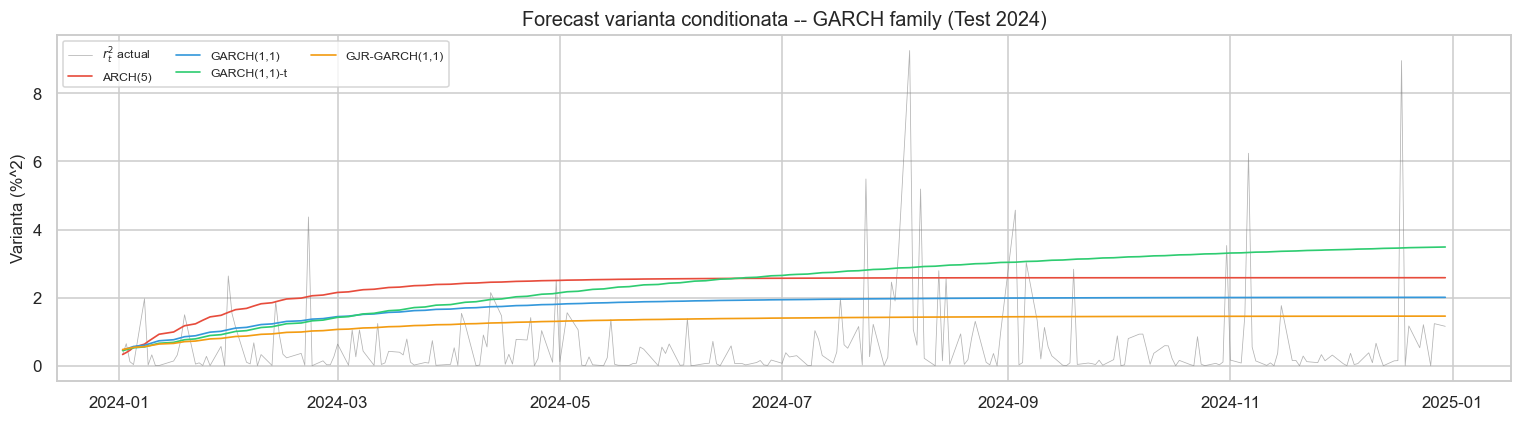

In [32]:
# ── Grafic forecast varianta ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(r_test.index, r_test.values**2, color='gray',
        linewidth=0.5, alpha=0.6, label='$r_t^2$ actual', zorder=1)
colors_g = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for (name, fc), col in zip(list(garch_vol_fc.items())[:4], colors_g):
    ax.plot(r_test.index[:len(fc)], fc, linewidth=1.1, color=col, label=name)
ax.set_title('Forecast varianta conditionata -- GARCH family (Test 2024)')
ax.set_ylabel('Varianta (%^2)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_09_garch_vol_forecast.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 3.8 Modele State Space si filtrul Kalman

Modelele in spatiul starilor descompun seria observata intr-o componenta **neobservabila**
(nivel, trend) estimata recursiv prin filtrul Kalman.

Specificatii:
- **Local Level** (LL): $r_t = \mu_t + \varepsilon_t$, $\mu_t = \mu_{t-1} + \eta_t$
- **Local Linear Trend** (LLT): adauga o componenta de trend stochastic

Incluse pentru acoperirea cerintei de curs. Pe randamente financiare,
performanta e de obicei comparabila cu modelele ETS.


In [36]:
# ── Local Level ──────────────────────────────────────────────────────
# RangeIndex numeric ca sa evitam erori de datetime la get_prediction
r_train_np = pd.Series(r_train.values)

print("Estimare Local Level Model...")
ll_fit = UnobservedComponents(r_train_np, level='local level').fit(disp=False)
print(ll_fit.summary())

Estimare Local Level Model...
                        Unobserved Components Results                         
Dep. Variable:                      y   No. Observations:                 1507
Model:                    local level   Log Likelihood               -2544.721
Date:                Wed, 10 Jun 2026   AIC                           5093.442
Time:                        23:00:30   BIC                           5104.076
Sample:                             0   HQIC                          5097.403
                               - 1507                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     1.7103      0.022     76.535      0.000       1.667       1.754
sigma2.level      2.504e-11   1.91e-05   1.31e-06      1.000   -3.75e-05    3.75e-0

In [37]:
# ── Local Linear Trend ───────────────────────────────────────────────
print("Estimare Local Linear Trend...")
llt_fit = UnobservedComponents(r_train_np, level='local linear trend').fit(disp=False)
print(llt_fit.summary())

Estimare Local Linear Trend...
                        Unobserved Components Results                         
Dep. Variable:                      y   No. Observations:                 1507
Model:             local linear trend   Log Likelihood               -2553.400
Date:                Wed, 10 Jun 2026   AIC                           5112.801
Time:                        23:00:32   BIC                           5128.751
Sample:                             0   HQIC                          5118.742
                               - 1507                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     1.6789      0.022     77.498      0.000       1.636       1.721
sigma2.level      1.763e-07   9.26e-05      0.002      0.998      -0.000       0.0

Local Level:        RMSE=0.7987  MAE=0.5909
Local Linear Trend: RMSE=0.7982  MAE=0.5902


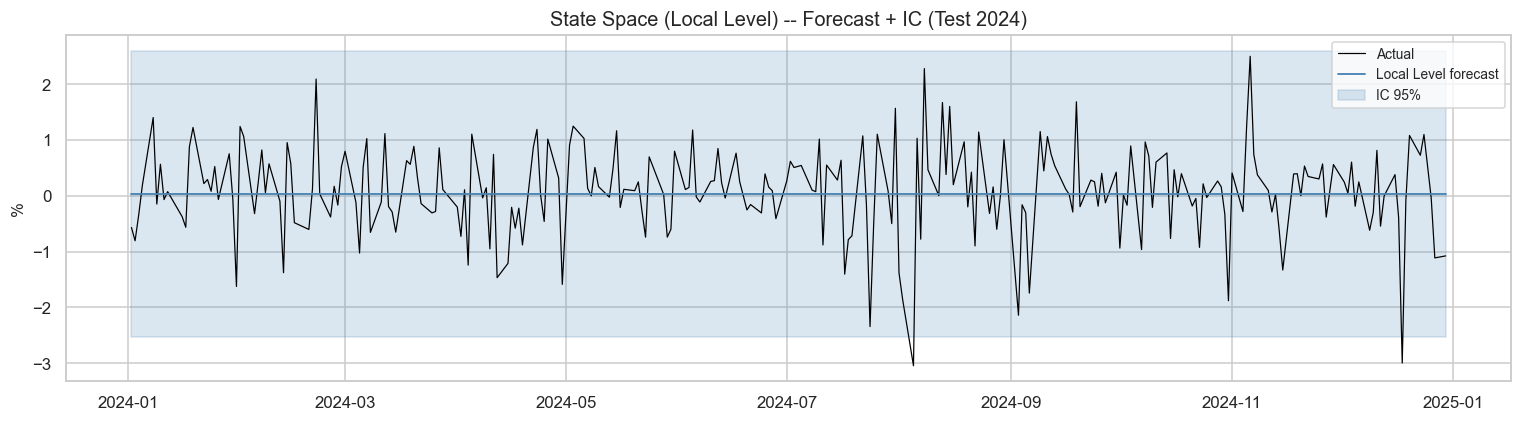

In [38]:
# ── Forecast + interval Kalman ───────────────────────────────────────
n_test = len(r_test)

ll_fc_vals  = ll_fit.forecast(n_test)
llt_fc_vals = llt_fit.forecast(n_test)

r_ll  = rmse(r_test.values[:n_test],  ll_fc_vals.values[:n_test])
m_ll  = mae_fn(r_test.values[:n_test], ll_fc_vals.values[:n_test])
r_llt = rmse(r_test.values[:n_test],  llt_fc_vals.values[:n_test])
m_llt = mae_fn(r_test.values[:n_test], llt_fc_vals.values[:n_test])

results['StateSpace_LL']  = {'RMSE': r_ll,  'MAE': m_ll}
results['StateSpace_LLT'] = {'RMSE': r_llt, 'MAE': m_llt}
print(f"Local Level:        RMSE={r_ll:.4f}  MAE={m_ll:.4f}")
print(f"Local Linear Trend: RMSE={r_llt:.4f}  MAE={m_llt:.4f}")

# IC Kalman prin indici numerici (evita eroarea de datetime index)
n_train = len(r_train)
try:
    ll_pred = ll_fit.get_prediction(start=n_train, end=n_train + n_test - 1)
    ci      = ll_pred.conf_int(alpha=0.05)
    ci_lo   = ci.iloc[:, 0].values
    ci_hi   = ci.iloc[:, 1].values
    fc_plot = ll_pred.predicted_mean.values
except Exception as e:
    print(f"get_prediction a esuat: {e} -- folosim IC ±1.96*sigma")
    fc_plot = ll_fc_vals.values[:n_test]
    sigma   = float(r_train.std())
    ci_lo   = fc_plot - 1.96 * sigma
    ci_hi   = fc_plot + 1.96 * sigma

n_plot = min(len(r_test), len(fc_plot), len(ci_lo))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(r_test.index, r_test.values,
        color='black', linewidth=0.8, label='Actual')
ax.plot(r_test.index[:n_plot], fc_plot[:n_plot],
        color='steelblue', linewidth=1.2, label='Local Level forecast')
ax.fill_between(r_test.index[:n_plot], ci_lo[:n_plot], ci_hi[:n_plot],
                alpha=0.2, color='steelblue', label='IC 95%')
ax.set_title('State Space (Local Level) -- Forecast + IC (Test 2024)')
ax.set_ylabel('%')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_10_statespace_forecast.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 3.9 Analiza spectrala

Periodograma descompune seria in frecvente si identifica cicluri dominante.

**Asteptam:**
- $r_t$: spectru plat ~= zgomot alb, fara cicluri clare
- $rv_{22d}$: putere mai mare la frecvente joase (persistenta volatilitatii)


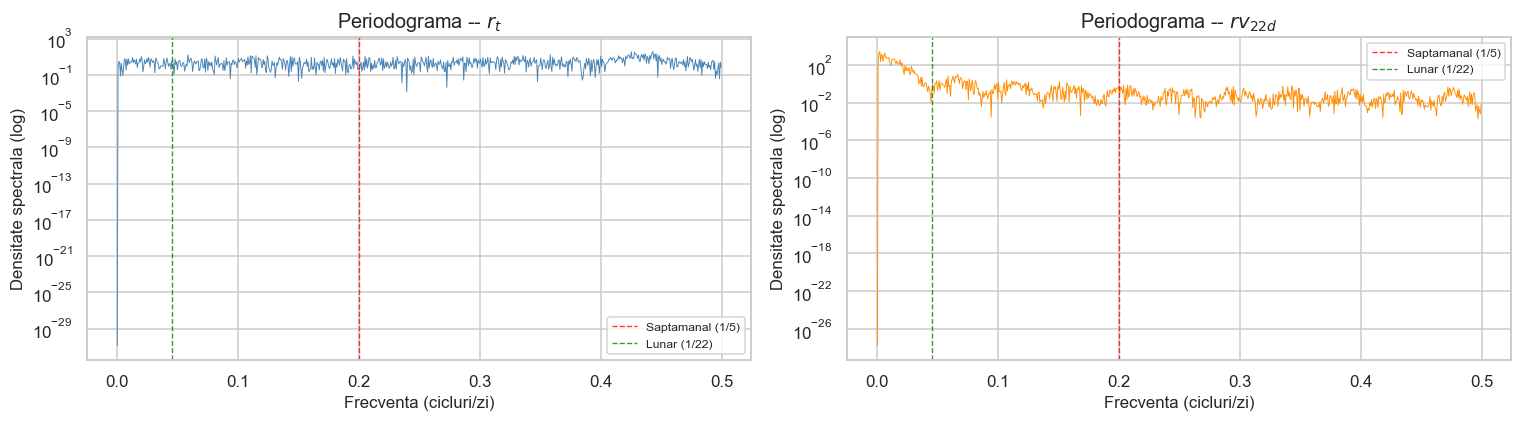

In [40]:
# ── Periodograma ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, serie, title, color in [
    (axes[0], r_train,  'Periodograma -- $r_t$',       'steelblue'),
    (axes[1], rv_train, 'Periodograma -- $rv_{22d}$',  'darkorange'),
]:
    freqs, power = periodogram(serie.dropna().values, fs=1.0)
    ax.semilogy(freqs, power, linewidth=0.6, color=color)
    ax.axvline(1/5,  color='red',   linestyle='--', linewidth=0.9,
               alpha=0.8, label='Saptamanal (1/5)')
    ax.axvline(1/22, color='green', linestyle='--', linewidth=0.9,
               alpha=0.8, label='Lunar (1/22)')
    ax.set_title(title)
    ax.set_xlabel('Frecventa (cicluri/zi)')
    ax.set_ylabel('Densitate spectrala (log)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_11_spectral.png', dpi=130, bbox_inches='tight')
plt.show()

print(
)


---
## 3.10 Modele neliniare: NNAR si SETAR

### NNAR (Neural Network AutoRegressive)

Inlocuieste ecuatia liniara ARIMA cu o retea neuronala:
$$r_t = f(r_{t-1}, r_{t-2}, ..., r_{t-p}) + \varepsilon_t$$

Folosim $p=5$ lag-uri (o saptamana) si un strat ascuns cu 16 neuroni.

### SETAR (Self-Exciting Threshold AR)

Comportament diferit in doua regimuri definite de pragul $\tau$:
$$r_t = \begin{cases}
\phi_1^{(0)} + \phi_1^{(1)} r_{t-1} + \varepsilon_t & \text{daca } r_{t-1} \leq \tau \\
\phi_2^{(0)} + \phi_2^{(1)} r_{t-1} + \varepsilon_t & \text{daca } r_{t-1} > \tau
\end{cases}$$

Pragul optim $\tau^*$ se identifica prin grid search pe percentilele 20-80.


In [41]:
# ── Functie utilitar pentru lag features ─────────────────────────────
def make_lag_df(series, n_lags):
    d = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        d[f'lag_{lag}'] = series.shift(lag)
    return d.dropna()

# ── NNAR ─────────────────────────────────────────────────────────────
P_LAGS = 5
LAG_COLS = [f'lag_{i}' for i in range(1, P_LAGS+1)]

train_df = make_lag_df(r_train, P_LAGS)
full_df  = make_lag_df(r_t, P_LAGS)
test_df  = full_df[full_df.index >= r_test.index[0]]

X_tr = train_df[LAG_COLS].values
y_tr = train_df['y'].values
X_te = test_df[LAG_COLS].values
y_te = test_df['y'].values

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

nnar = MLPRegressor(hidden_layer_sizes=(16,), activation='relu',
                     max_iter=2000, random_state=42, early_stopping=True)
nnar.fit(X_tr_sc, y_tr)
nnar_preds = nnar.predict(X_te_sc)

r_nnar = rmse(y_te, nnar_preds)
m_nnar = mae_fn(y_te, nnar_preds)
results['NNAR(5,16)'] = {'RMSE': r_nnar, 'MAE': m_nnar}
print(f"NNAR(5 lags, 16 hidden)  RMSE={r_nnar:.4f}  MAE={m_nnar:.4f}")


NNAR(5 lags, 16 hidden)  RMSE=0.8082  MAE=0.5955


In [42]:
# ── SETAR ────────────────────────────────────────────────────────────
def fit_setar_predict(train_series, full_series, threshold, delay=1, p=1):
    lag_cols_s = [f'lag_{i}' for i in range(1, p+1)]
    n_lags_s   = max(p, delay)
    df_s = make_lag_df(train_series, n_lags_s)
    regime_col = f'lag_{delay}'
    regime = df_s[regime_col] <= threshold
    mods = {}
    for rv in [True, False]:
        mask = regime == rv
        if mask.sum() < 10:
            continue
        lr = LinearRegression()
        lr.fit(df_s.loc[mask, lag_cols_s], df_s.loc[mask, 'y'])
        mods[rv] = lr
    # Predict pe full_series
    df_full = make_lag_df(full_series, n_lags_s)
    preds = {}
    for idx in df_full.index:
        rv = df_full.loc[idx, regime_col] <= threshold
        key = rv if rv in mods else (not rv)
        if key in mods:
            x = df_full.loc[idx, lag_cols_s].values.reshape(1, -1)
            preds[idx] = mods[key].predict(x)[0]
    return pd.Series(preds), mods

print("SETAR grid search pe prag tau (percentile 20-80)...")
thresholds = np.percentile(r_train.dropna(), np.arange(20, 81, 5))
setar_rows = []
for tau in thresholds:
    preds_all, _ = fit_setar_predict(r_train, r_train, tau)
    sse = ((r_train[preds_all.index] - preds_all)**2).sum()
    setar_rows.append({'tau': tau, 'SSE': sse})

setar_grid = pd.DataFrame(setar_rows)
best_tau   = setar_grid.loc[setar_grid['SSE'].idxmin(), 'tau']
print(f"Prag optim tau* = {best_tau:.4f}")

preds_full, smods = fit_setar_predict(r_train, r_t, best_tau)
preds_test = preds_full[preds_full.index.isin(r_test.index)]
common     = r_test.index.intersection(preds_test.index)

r_setar = rmse(r_test[common].values, preds_test[common].values)
m_setar = mae_fn(r_test[common].values, preds_test[common].values)
results[f'SETAR(tau={best_tau:.3f})'] = {'RMSE': r_setar, 'MAE': m_setar}
print(f"SETAR  RMSE={r_setar:.4f}  MAE={m_setar:.4f}")

bear = (r_train <= best_tau).sum()
bull = (r_train > best_tau).sum()
print(f"Regim BEAR (r_t <= {best_tau:.3f}): {bear} obs ({100*bear/len(r_train):.1f}%)")
print(f"Regim BULL (r_t > {best_tau:.3f}): {bull} obs ({100*bull/len(r_train):.1f}%)")


SETAR grid search pe prag tau (percentile 20-80)...
Prag optim tau* = 0.3812
SETAR  RMSE=0.8118  MAE=0.6074
Regim BEAR (r_t <= 0.381): 979 obs (65.0%)
Regim BULL (r_t > 0.381): 528 obs (35.0%)


---
## 3.11 Compararea performantei predictive

### Tabel sintetic

Colectam metricile tuturor modelelor si le ordonam dupa RMSE.

### Testul Diebold-Mariano (DM)

Verifica daca diferenta de performanta intre doua modele este **statistic semnificativa**.

$H_0$: modelele au aceeasi putere predictiva medie

$$DM = \frac{\bar{d}}{\sqrt{\hat{V}(\bar{d})/n}} \xrightarrow{d} N(0,1)$$

unde $d_t = L(e_{1t}) - L(e_{2t})$ este diferenta punct-cu-punct a pierderilor.

Comparam toate modelele fata de **Naive (mean)** ca benchmark minimal.


In [43]:
# ── Tabel sintetic ───────────────────────────────────────────────────
res_df = pd.DataFrame(results).T.apply(pd.to_numeric, errors='coerce')
res_df = res_df.sort_values('RMSE')

print("=== TABEL COMPARATIV -- TOATE MODELELE ===")
print(res_df.round(4).to_string())

res_df.round(4).to_csv(FIG_PATH / 'nb02_results.csv')
res_df.round(4).to_latex(FIG_PATH / 'nb02_results.tex',
                          float_format='%.4f', na_rep='-')
print("\nOK Salvat: nb02_results.csv + .tex")


=== TABEL COMPARATIV -- TOATE MODELELE ===
                           RMSE     MAE   QLIKE
ETS_Holt                 0.7974  0.5881     NaN
StateSpace_LLT           0.7982  0.5902     NaN
StateSpace_LL            0.7987  0.5909     NaN
ETS_SES                  0.7987  0.5909     NaN
Naive_mean               0.7987  0.5909     NaN
SARIMA(1,0,1)(1,0,1)[5]  0.7990  0.5912     NaN
NNAR(5,16)               0.8082  0.5955     NaN
ETS_Holt-Winters         0.8095  0.5938     NaN
SETAR(tau=0.381)         0.8118  0.6074     NaN
ARIMA(3, 0, 3)           0.8229  0.6203     NaN
ETS_Holt-Winters_rv      0.9842  0.7450     NaN
ETS_SES_rv               1.1992  0.8748     NaN
ETS_Holt_rv              1.2287  0.9746     NaN
GJR-GARCH(1,1)_vol       1.3703  1.0852  1.8533
GARCH(1,1)_vol           1.6633  1.4616  2.0270
ARCH(5)_vol              2.1300  1.9705  2.2268
GARCH(1,1)-t_vol         2.2870  2.0407  2.2202

OK Salvat: nb02_results.csv + .tex


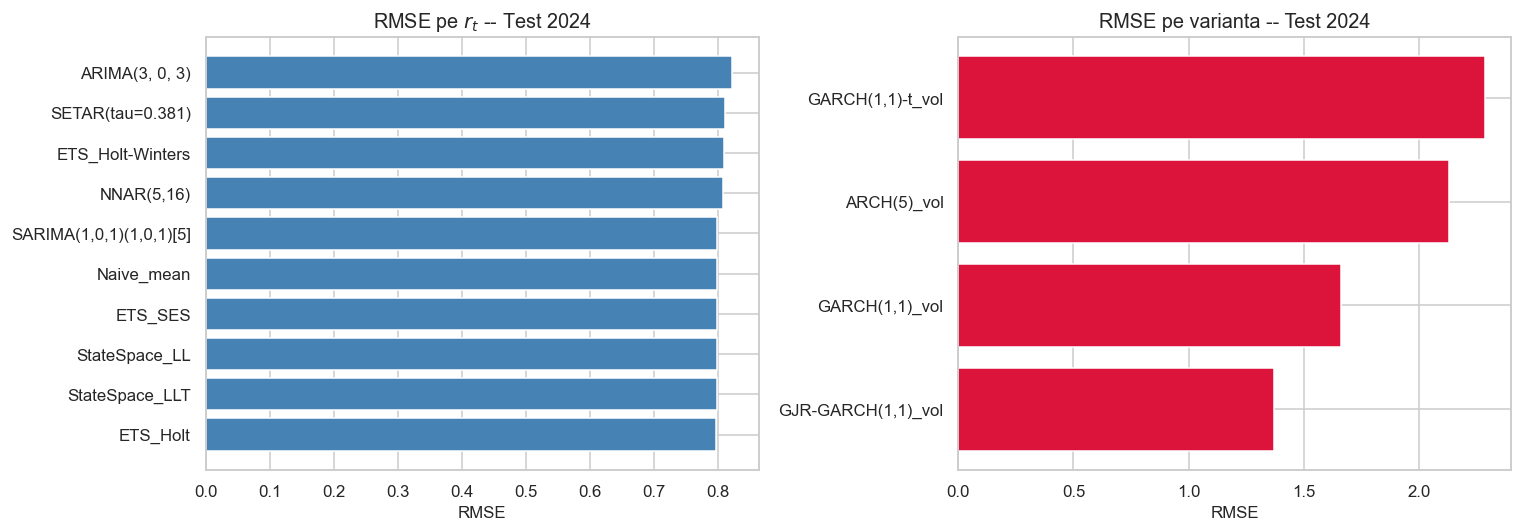

In [44]:
# ── Grafic RMSE comparativ ───────────────────────────────────────────
rt_res  = {k: v for k, v in results.items()
           if '_vol' not in k and '_rv' not in k}
vol_res = {k: v for k, v in results.items() if '_vol' in k}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_rmse(ax, d, title, color):
    names = list(d.keys())
    vals  = [d[k].get('RMSE', np.nan) for k in names]
    order = np.argsort(vals)
    ax.barh([names[i] for i in order], [vals[i] for i in order],
            color=color, edgecolor='white')
    ax.set_title(title); ax.set_xlabel('RMSE')

plot_rmse(axes[0], rt_res,  'RMSE pe $r_t$ -- Test 2024',       'steelblue')
if vol_res:
    plot_rmse(axes[1], vol_res, 'RMSE pe varianta -- Test 2024', 'crimson')

plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_12_rmse_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


In [45]:
# ── Testul Diebold-Mariano ────────────────────────────────────────────
def diebold_mariano(actual, pred1, pred2, loss='mse'):
    """
    Test DM (Harvey, Leybourne & Newbold, 1997).
    Returneaza: dm_stat, p_value (two-sided).
    H0: pred1 si pred2 au aceeasi acuratete predictiva.
    """
    if loss == 'mse':
        d = (actual - pred1)**2 - (actual - pred2)**2
    else:
        d = np.abs(actual - pred1) - np.abs(actual - pred2)
    n      = len(d)
    d_mean = d.mean()
    var_d  = np.var(d, ddof=1) / n
    dm_stat = d_mean / np.sqrt(max(var_d, 1e-12))
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_val

actual = r_test.values
bench  = np.full(len(actual), r_train.mean())   # benchmark: Naive

# Colectam forecast-urile disponibile
dm_forecasts = {
    'Naive (mean)':                 bench,
    f'ARIMA{best_order}':           arima_preds[:len(actual)],
    'NNAR(5,16)':                   nnar_preds[:len(y_te)],
    'StateSpace_LL':                ll_fc.values[:len(actual)],
    'StateSpace_LLT':               llt_fc.values[:len(actual)],
    'ETS_SES':                      ets_fits['SES'].forecast(len(r_test)).values[:len(actual)],
    'ETS_Holt-Winters':             ets_fits['Holt-Winters'].forecast(len(r_test)).values[:len(actual)],
}

print("=== TEST DIEBOLD-MARIANO fata de Naive (mean forecast) ===")
print(f"{'Model':<30} {'DM stat':>9} {'p-value':>9} {'Semnificativ?':>15} {'Mai bun?':>10}")
print("─" * 80)

for name, preds in dm_forecasts.items():
    if name == 'Naive (mean)':
        continue
    try:
        n  = min(len(actual), len(preds), len(bench))
        dm, p = diebold_mariano(actual[:n], preds[:n], bench[:n])
        sig  = 'Da (5%)' if p < 0.05 else 'Nu'
        bett = ('Model  OK' if (p < 0.05 and dm < 0) else
                'Naive  ATENTIE' if (p < 0.05 and dm > 0) else '-')
        print(f"  {name:<28} {dm:9.3f} {p:9.4f} {sig:>15} {bett:>10}")
    except Exception as e:
        print(f"  {name:<28} eroare: {e}")


=== TEST DIEBOLD-MARIANO fata de Naive (mean forecast) ===
Model                            DM stat   p-value   Semnificativ?   Mai bun?
────────────────────────────────────────────────────────────────────────────────
  ARIMA(3, 0, 3)                   2.084    0.0372         Da (5%) Naive  ATENTIE
  NNAR(5,16)                       0.931    0.3518              Nu          -
  StateSpace_LL                   -0.002    0.9987              Nu          -
  StateSpace_LLT                  -0.790    0.4295              Nu          -
  ETS_SES                         -0.000    1.0000              Nu          -
  ETS_Holt-Winters                 1.829    0.0674              Nu          -


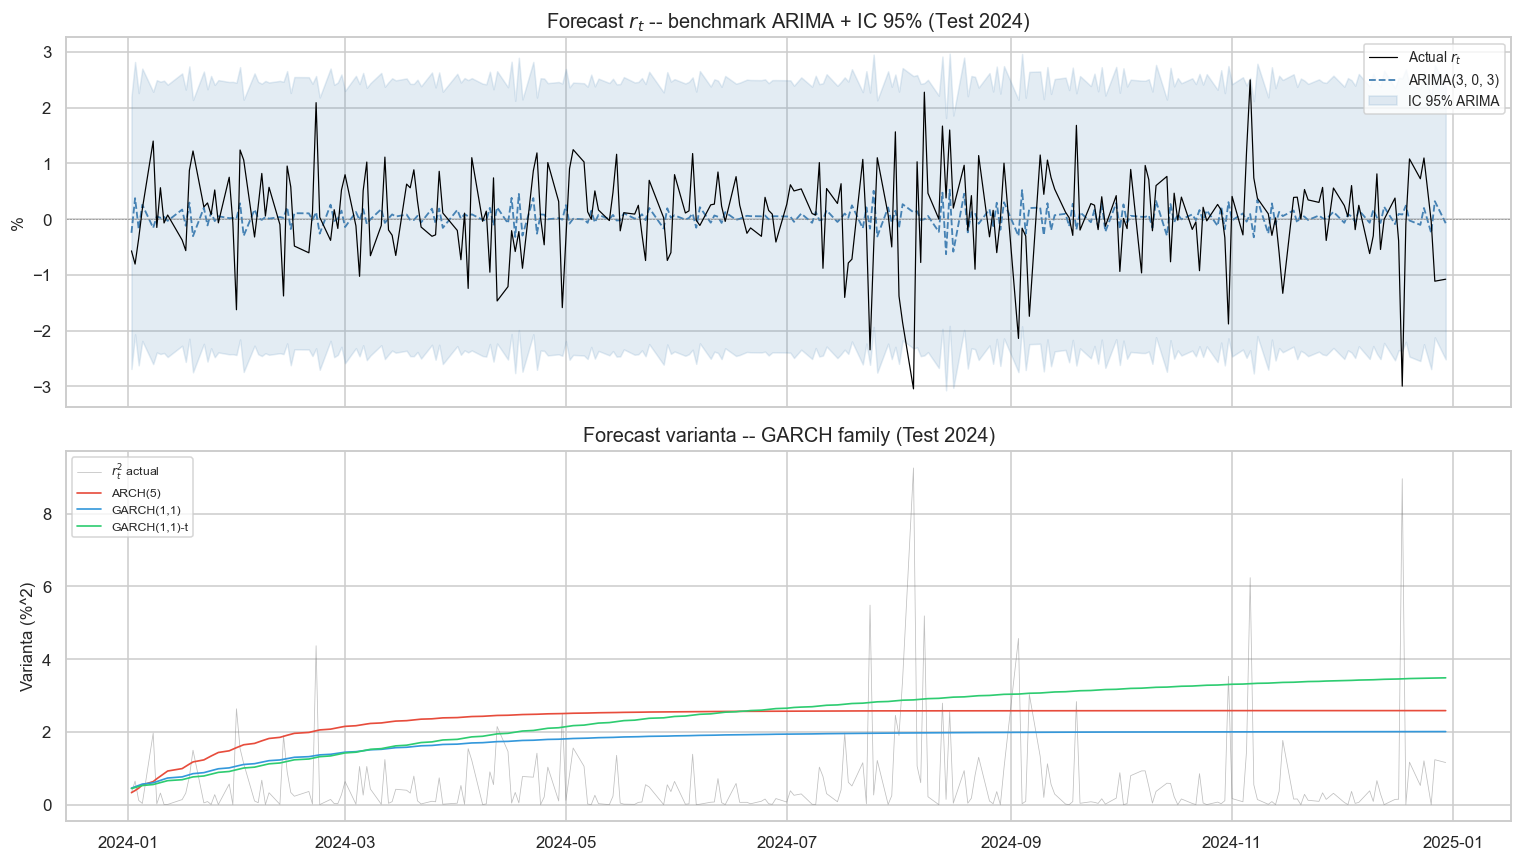

: 

In [ ]:
# ── Forecast final -- plot sintetic cu IC ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1 -- randamente
axes[0].plot(r_test.index, r_test.values, color='black',
             linewidth=0.8, label='Actual $r_t$', zorder=3)
axes[0].plot(r_test.index, arima_preds, color='steelblue',
             linewidth=1.2, linestyle='--', label=f'ARIMA{best_order}')
sig_r = float(resid.std())
axes[0].fill_between(r_test.index, arima_preds - 1.96*sig_r,
                     arima_preds + 1.96*sig_r, alpha=0.15,
                     color='steelblue', label='IC 95% ARIMA')
axes[0].axhline(0, color='gray', linewidth=0.4, linestyle='--')
axes[0].set_title('Forecast $r_t$ -- benchmark ARIMA + IC 95% (Test 2024)')
axes[0].set_ylabel('%')
axes[0].legend(fontsize=9)

# Panel 2 -- volatilitate GARCH
axes[1].plot(r_test.index, r_test.values**2, color='gray',
             linewidth=0.5, alpha=0.5, label='$r_t^2$ actual')
cols_g = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for (name, fc), col in zip(list(garch_vol_fc.items())[:3], cols_g):
    axes[1].plot(r_test.index[:len(fc)], fc,
                 linewidth=1.1, color=col, label=name)
axes[1].set_title('Forecast varianta -- GARCH family (Test 2024)')
axes[1].set_ylabel('Varianta (%^2)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_PATH / 'nb02_13_final_forecast.png', dpi=130, bbox_inches='tight')
plt.show()
